# Exploratory Data Analysis (EDA)

In [6]:
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for NLP
import re
import string
from wordcloud import WordCloud
from collections import Counter
from sklearn.utils import resample
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer

In [9]:
# Initializing NLTK
nltk.download('stopwords')
nltk.download('punkt')
STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**1. Loading the Dataset**

In [10]:
df = pd.read_excel('Sentiment_Analysis_Dataset.xlsx')

In [11]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [12]:
df.columns = [col.capitalize() for col in df.columns]

In [13]:
# Display the resulting column names and the first few rows
print("Updated Column Names:", df.columns.tolist())

Updated Column Names: ['Title', 'Rating', 'Body']


In [14]:
df.head()

,Title,Rating,Body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [15]:
df.shape

(1440, 3)

In [16]:
# Pre-processing: Map Rating to Sentiment and rename columns for clarity
# 1-2: Negative, 3: Neutral, 4-5: Positive

df['Review_Text'] = df['Body'].astype(str)

In [17]:
def map_sentiment(rating):
    if rating <= 2: return 'Negative'
    elif rating == 3: return 'Neutral'
    else: return 'Positive'

df['Sentiment'] = df['Rating'].apply(map_sentiment)
df.head()

,Title,Rating,Body,Review_Text,Sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...","Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...","Not worth buying....faulty software, poor disp...",Negative


**2. Data Structure & Quality Assessment**

In [18]:
# Null Values detection
print(f"Missing Values:\n{df[['Review_Text', 'Sentiment']].isnull().sum()}\n")

Missing Values:
Review_Text    0
Sentiment      0
dtype: int64



In [19]:
# Duplicate detection
duplicates = df['Review_Text'].duplicated().sum()
print(f"Duplicates Found: {duplicates}")
df = df.drop_duplicates(subset=['Review_Text']).reset_index(drop=True)
print("Duplicates removed.\n")

Duplicates Found: 0
Duplicates removed.



In [20]:
print(f'Rating value Counts: \n{df['Rating'].value_counts()}')

Rating value Counts: 
Rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64


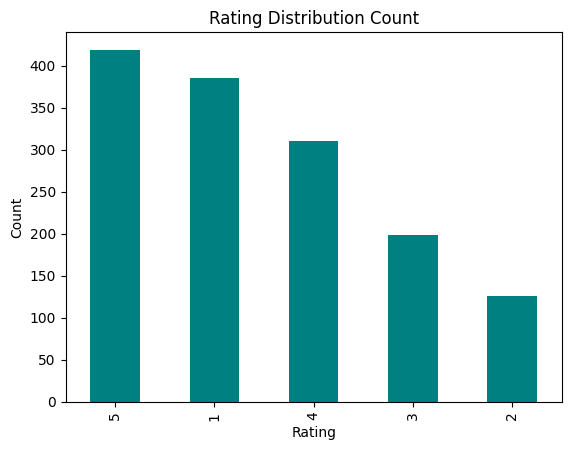

In [21]:
# Bar Plot to Visulaize the total counts of each rating

df['Rating'].value_counts().plot(kind='bar', color='teal')
plt.title('Rating Distribution Count')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [22]:
#Finding the % distribution of each rating

print(f'Rating value count - Percentage Distribution: \n{round(df['Rating'].value_counts()/df.shape[0]*100,2)}')

Rating value count - Percentage Distribution: 
Rating
5    29.10
1    26.81
4    21.53
3    13.82
2     8.75
Name: count, dtype: float64


In [23]:
# Class Balance Analysis
balance = df['Sentiment'].value_counts(normalize=True) * 100
print("Class Distribution (%):")
print(balance)

Class Distribution (%):
Sentiment
Positive    50.625000
Negative    35.555556
Neutral     13.819444
Name: proportion, dtype: float64


C:\Users\Jawad\AppData\Local\Temp\ipykernel_15744\3538896544.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


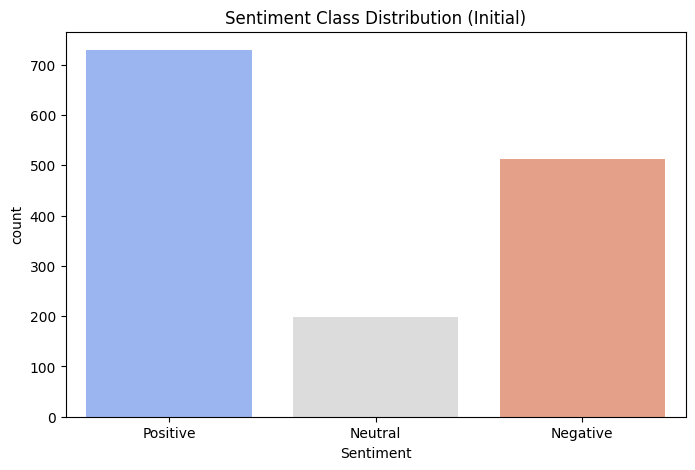

In [24]:
# Visualization: Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Class Distribution (Initial)')
plt.show()

**3. Textual Statistical Analysis & Ooutlier Removal**

In [25]:
df['word_count'] = df['Review_Text'].apply(lambda x: len(x.split()))
df['char_count'] = df['Review_Text'].apply(lambda x: len(x))

In [26]:
# Corpus Metrics
print(f"Avg Word Count: {df['word_count'].mean():.2f}")
print(f"Max Word Count: {df['word_count'].max()}")

Avg Word Count: 52.89
Max Word Count: 385


In [27]:
# For reference and can be used in data modelling section
# Punctuation Density (Emotional Intensity)
df['exclam_count'] = df['Review_Text'].apply(lambda x: x.count('!'))
df['ques_count'] = df['Review_Text'].apply(lambda x: x.count('?'))

In [28]:
# OUTLIER IDENTIFICATION & REMOVAL (IQR Method)
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [29]:
outlier_count = len(df[(df['word_count'] < lower_bound) | (df['word_count'] > upper_bound)])
print(f"Outliers Identified (by word count): {outlier_count}")

Outliers Identified (by word count): 94


In [30]:
# Removing Outliers
df_cleaned = df[(df['word_count'] >= lower_bound ) & (df['word_count'] <= upper_bound)].copy()
print(f"Dataset size after outlier removal: {len(df_cleaned)}")

Dataset size after outlier removal: 1346


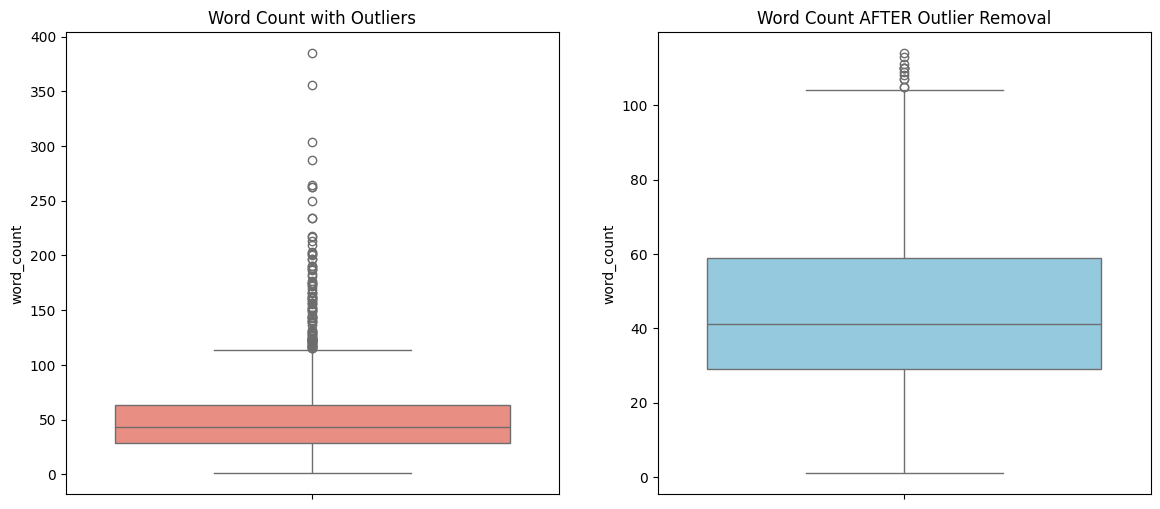

In [31]:
# Visualization :
# 1.

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['word_count'], color='salmon')
plt.title('Word Count with Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['word_count'], color='skyblue')
plt.title('Word Count AFTER Outlier Removal')
plt.show()

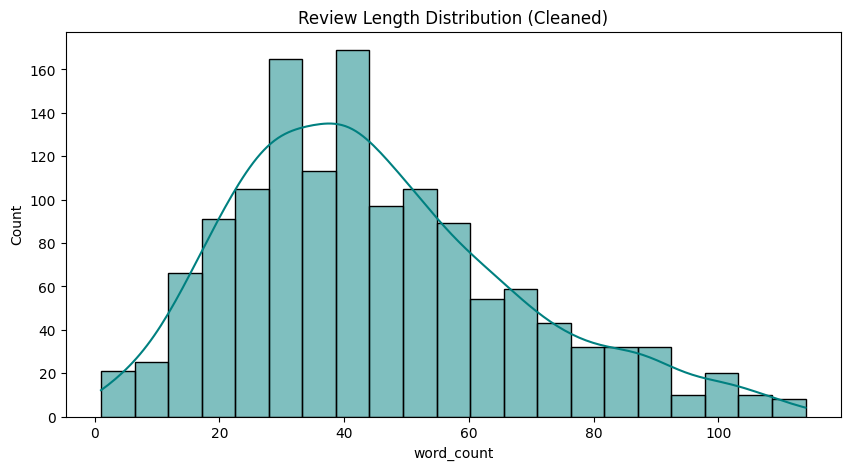

In [32]:
# 2. Histogram

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['word_count'], kde=True, color='teal')
plt.title('Review Length Distribution (Cleaned)')
plt.show()

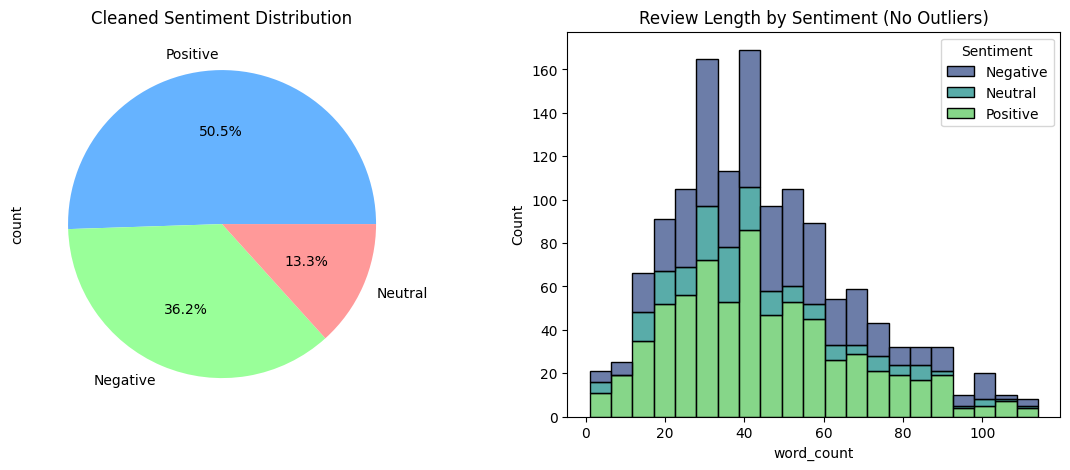

In [33]:
# 3. Pie chart and Bar_chat
# CLASS BALANCE & TEXT DISTRIBUTION

plt.figure(figsize=(14, 5))

# Sentiment Balance
plt.subplot(1, 2, 1)
df_cleaned['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Cleaned Sentiment Distribution')

# Length Distribution
plt.subplot(1, 2, 2)
sns.histplot(data=df_cleaned, x='word_count', hue='Sentiment', multiple="stack", palette='viridis')
plt.title('Review Length by Sentiment (No Outliers)')
plt.show()

**4. Word Frequency & Semantic Exploration**

In [34]:
def show_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=STOP_WORDS).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

TypeError: asarray() got an unexpected keyword argument 'copy'

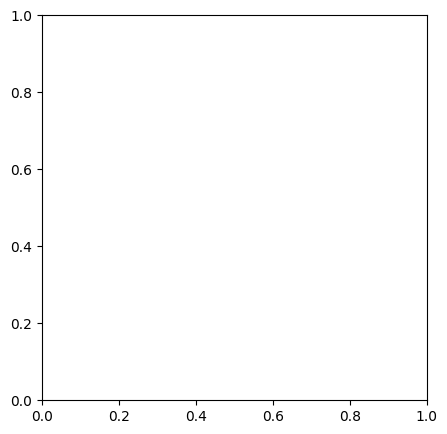

In [35]:
# Visuals of Global WordCloud
show_wordcloud(" ".join(df_cleaned['Review_Text']), "Global Themes")

In [ ]:
# N-Gram Extraction (Top 10 Bigrams)
def get_ngrams(text_list, n=2):
    all_words = " ".join(text_list).lower()
    tokens = [w for w in nltk.word_tokenize(all_words) if w.isalnum() and w not in STOP_WORDS]
    n_grams = ngrams(tokens, n)
    return Counter(n_grams).most_common(10)

In [ ]:
# Important when we used N-Gram Extraction - as it helps to correctly identify the boundaries between two worrds (e.g: "not happy")
nltk.download('punkt_tab')

In [ ]:
print("Top 10 Bigrams (Context):", get_ngrams(df_cleaned['Review_Text'], 2))

# Feature Engineering and Pre-processing

**5. Preprocessing, Feature Insights & Data Balancing**

In [ ]:
# Feature Engineering: Shouting (All Caps)
df_cleaned['shouting_ratio'] = df_cleaned['Review_Text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)

In [ ]:
# DATA BALANCING (Upsampling Minority Classes)
#  We balance the data to match the majority class count
majority_class = df_cleaned[df_cleaned.Sentiment == 'Positive']
neutral_class = df_cleaned[df_cleaned.Sentiment == 'Neutral']
negative_class = df_cleaned[df_cleaned.Sentiment == 'Negative']

In [ ]:
neutral_upsampled = resample(neutral_class, replace=True, n_samples=len(majority_class), random_state=42)
negative_upsampled = resample(negative_class, replace=True, n_samples=len(majority_class), random_state=42)

In [ ]:
df_balanced = pd.concat([majority_class, neutral_upsampled, negative_upsampled])
print(f"Balanced Dataset Size: {len(df_balanced)}")

In [ ]:
print("New Class Counts:\n", df_balanced.Sentiment.value_counts())